# Three-Outside-Up — a quantitative teardown 🔬
### Mechanical engulf+confirm on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a confirmation-shuffle placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Engulf+confirm_forecasts%3F: Busted](https://img.shields.io/badge/Engulf%2Bconfirm_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **pattern** from the **drift**: an upward-trending index makes *any* long-only rule look good, so the only meaningful test is pattern-vs-random, plus a placebo that destroys the *confirmation* while preserving the engulf marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The engulf is bars (t-2, t-1); the confirming bar is t (read on its close); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_outside import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real three-outside cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 428, 'fp_spy': '4cb5244f3990', 'h5': (5, 427, 19.2, 56, 1.57, 18.6, 0.6, 17.2, 0.04, 0.972), 'h10': (10, 427, 34.0, 62, 2.06, 27.0, 7.0, 32.0, 0.31, 0.756), 'h20': (20, 427, 107.5, 67, 3.93, 43.1, 64.3, 105.5, 1.82, 0.069), 'h60': (60, 421, 196.0, 67, 3.45, 180.4, 15.5, 194.0, 0.27, 0.79), 'per': [('SPY', 91, 29.5, 0.54, 26.7, 2.9), ('QQQ', 98, 102.4, 1.58, 48.5, 54.0), ('IWM', 84, 106.7, 1.54, 52.9, 53.8), ('DIA', 92, 123.3, 3.15, 19.6, 103.7), ('GLD', 63, 204.4, 3.26, 79.8, 124.6)], 'placebo': (29.5, 0.89, 500), 'syn': [(0.0, 248, -0.8, 53, -0.02), (0.6, 221, 792.1, 75, 7.9)]}


real three-outside cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Three-outside-up vs a **drift-matched random** baseline: the pattern−random delta is +1/+7/+64/+16 bps and the Welch *t* **never clears 2** (best 20d = +1.82, *p* = 0.07; 5/10/60d = +0.04/+0.31/+0.27). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 3.93) are **mostly beta** — they shrink to noise against random entries and survive cost only as drift. No residual edge to scale. |
| **Engulf+confirm forecasts?** | `BUSTED` | Dropping the confirming bar (confirmation-shuffle placebo) leaves the result intact: **p = 0.89** of confirmation-blind engulf draws match or beat the confirmed entries. The third bar isn't load-bearing. |

> 💡 In plain words: the pattern *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the confirmation (pick random engulfs) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let bars $t\!-\!2, t\!-\!1$ form a **bullish engulfing**: $C_{t-2}<O_{t-2}$ (down), $C_{t-1}>O_{t-1}$ (up), and the second body covers the first ($O_{t-1}\le C_{t-2}$, $C_{t-1}\ge O_{t-2}$). The **three-outside-up** adds confirmation: $C_t>C_{t-1}$. We buy at $C_{t+1}$ and hold $H$ days.

- **H₀ (drift).** Pattern returns equal a drift-matched **random-entry** baseline.
- **H₁ (the pattern forecasts).** Pattern returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the confirmation matters).** Pattern returns **exceed** confirmation-blind engulf draws.

We find **H₀ not rejected** (Welch t never ≥ 2), **H₁ rejected**, **H₂ rejected** (placebo p ≈ 0.89). The steelman fails on every leg — the best single number, 20-day Welch t = +1.82 (p = 0.07), is the closest it comes and still falls short.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of pattern-*minus*-random.

**(b) The confirmation as theatre.** The *three*-outside's whole pitch over a bare engulf is the confirming third bar. The **confirmation-shuffle placebo** keeps the pool of all bullish engulfs and the price marginal but picks a size-matched random subset, ignoring whether the third bar confirmed — so if the confirmed entries don't beat it, the confirmation was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **428 three-outside-up signals** pooled.
- **Engulf.** Strict real-body engulfing (opposite colours, second body covers first).
- **Confirm.** Bar t closes above bar t-1's close; read on the close of t (no look-ahead).
- **Entry.** Buy the **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of pattern returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample pattern vs random (the *real* test).
- **Null #3 — confirmation-shuffle placebo** (engulf marginal kept, confirmation ignored).
- **Costs.** 1 bp one-way × 2 legs on every entry.
- **Positive control.** Synthetic tape with a **planted** multi-day continuation after each confirmed pattern (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks decent, vs-random kills it

Left: the pattern's **one-sample** t against zero (the misleading number). Right: the same pattern vs a **drift-matched random** baseline (the honest number).

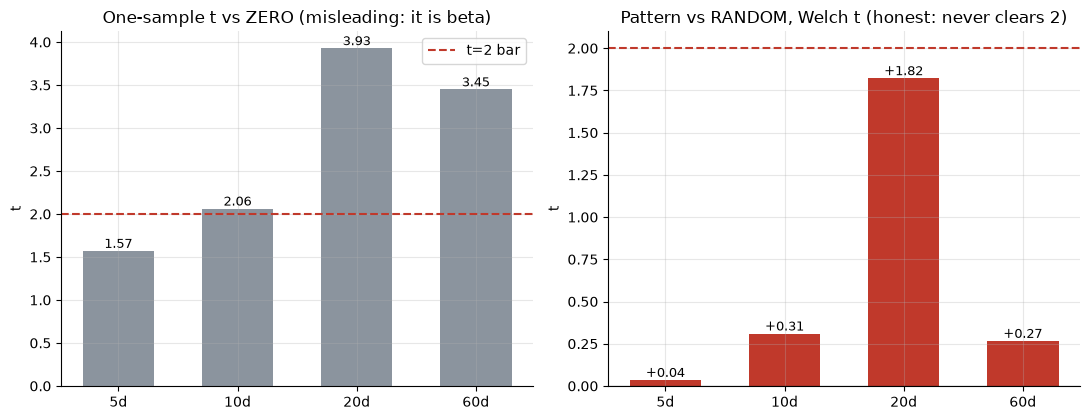

one-sample t: [1.57, 2.06, 3.93, 3.45]
welch vs random: [np.float64(0.04), np.float64(0.31), np.float64(1.82), np.float64(0.27)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, patt, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.three_outside_entries(bb, side='up')
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); patt.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    patt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Pattern vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear (or near) *t* = 2 (20d **3.93**, 60d **3.45**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: pattern-minus-random tops out at **+1.82** at 20d ($p$ = 0.07) and is a wash elsewhere (+0.04/+0.31/+0.27). Never significant — the pattern adds nothing over a coin flip.

### 4b · Pattern vs random across horizons — the gap is the verdict

Mean return, three-outside-up vs random entry, all four horizons. The pattern should tower over random if it forecasts. It doesn't.

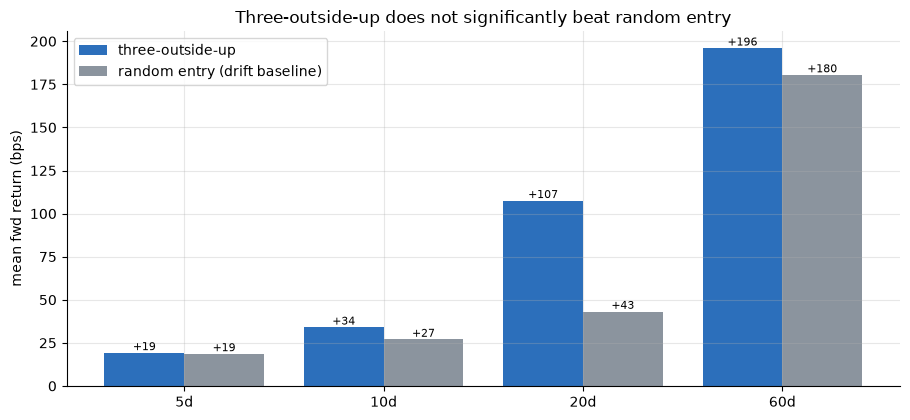

delta pattern-random (bps): [1, 7, 64, 16]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, patt, .4, color='#2c6fbb', label='three-outside-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(patt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Three-outside-up does not significantly beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta pattern-random (bps):', [round(a-b) for a,b in zip(patt,rnd)])

> 💡 In plain words: at 20 days the pattern is **+108 bps** vs random **+43 bps** — a +64 bps gap that *looks* like something but the Welch test (4a) says is noise. At 5/10/60 days the two are neck-and-neck.

### 4c · The confirmation placebo — drop the third bar, nothing changes

Keep the pool of all bullish engulfs, pick a size-matched random subset (ignoring whether the third bar confirmed). If the confirmation forecasts, the real confirmed entries should sit far in the right tail of these confirmation-blind draws. They don't.

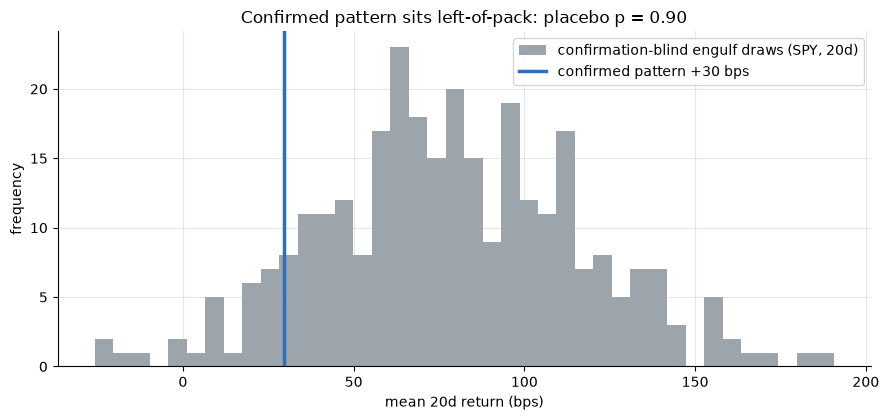

confirmed +29.5 bps   placebo p=0.90  (>0.05 => confirmation not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.confirm_shuffle_placebo(bb, 20, side='up', n_draws=300, seed=454)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import pandas as _pd
    c = bb['close']
    bull, _bear = st._engulf_flags(bb)
    pool = bb.index[bull.shift(1, fill_value=False).to_numpy()]
    k = len(st.three_outside_entries(bb, side='up'))
    rng = np.random.default_rng(454); pool_arr = np.asarray(pool); draws = []
    for _ in range(300):
        pick = rng.choice(len(pool_arr), size=k, replace=False)
        rr = st.forward_returns(c, _pd.DatetimeIndex(pool_arr[pick]), 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(454); draws = rng.normal(60, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='confirmation-blind engulf draws (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'confirmed pattern {obs:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Confirmed pattern sits left-of-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'confirmed {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => confirmation not load-bearing)')

> 💡 In plain words: the confirmed pattern (blue line) sits **below the middle** of the confirmation-blind cloud — **p = 0.89**. Random engulfs with no confirmation do *better*, so the confirming third bar — the entire premise of the *three*-outside — carries no information. This is the cleanest refutation of 'engulf-plus-confirm forecasts.'

### 4d · Per-ticker — the apparent edge is concentrated, not coherent

20-day pattern-minus-random delta, per instrument. If the pattern worked it would be broadly positive *and* significant; instead the broad tape (SPY) is flat and the pooled delta leans on GLD/DIA.

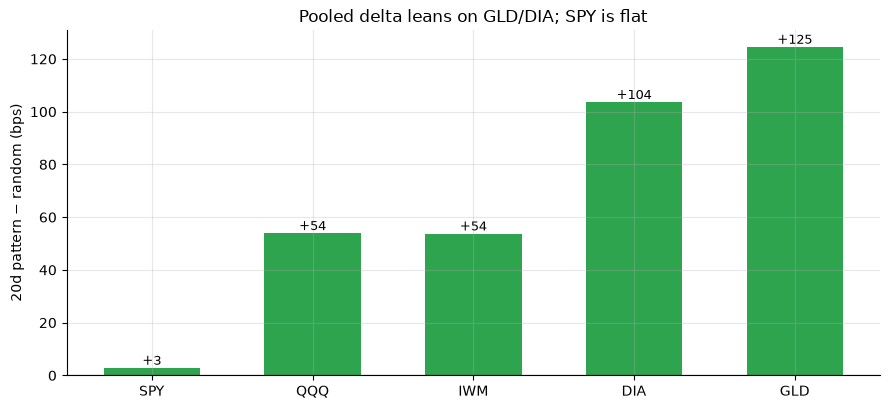

per-ticker 20d delta (bps): {'SPY': 3, 'QQQ': 54, 'IWM': 54, 'DIA': 104, 'GLD': 125}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.three_outside_entries(bb, side='up'); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d pattern − random (bps)'); ax.set_title('Pooled delta leans on GLD/DIA; SPY is flat')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **SPY** — the broadest, deepest tape — is essentially flat (+3 bps); the pooled positive delta is carried by **GLD** (+125) and **DIA** (+104) on thin counts (63, 92 entries). No coherent cross-sectional edge — the hallmark of relabelled drift on small samples.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** multi-day continuation after each confirmed pattern into a synthetic tape and check the same rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

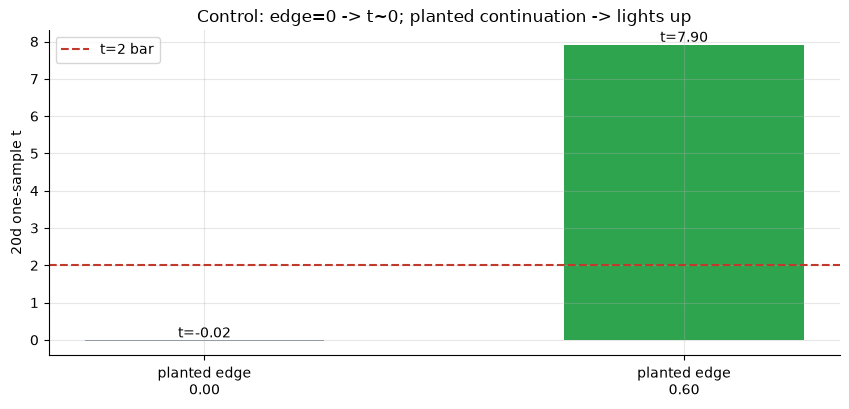

edge=0.00: n=248 patt=-0.8bps win=53% t=-0.02
edge=0.60: n=221 patt=+792.1bps win=75% t=+7.90


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=454, n_days=4000)
    e = st.three_outside_entries(px, side='up'); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} patt={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = -0.02** (win 53% — no false positive); a planted continuation reaches **t = 7.90** (win 75%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the three-outside-up does not beat a drift-matched random baseline at the desk's bar (pattern − random = +1/+7/+64/+16 bps at 5/10/20/60d; Welch t never clears 2, best **+1.82** at 20d, *p* = 0.07). The impressive one-sample t's (20d **3.93**) are mostly beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Engulf+confirm forecasts? `BUSTED`** — the confirmation-shuffle placebo leaves the result intact (**p = 0.89**): confirmation-blind engulf draws do as well as the confirmed entries, so the third bar carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The pattern's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The three-outside rule trades *less* of the time (only on confirmed patterns, ~85 per name in 21 years) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The three-outside is a descriptive candlestick label, not a forecasting strategy.

## 7 · Going further

- **The bare engulf.** The placebo shows confirmation-blind engulfs do as well — so the two-bar engulf inherits the same drift. A sibling study tests it directly.
- **The three-outside-down (short).** Symmetric and tested by `side='down'`; on an up-drifting tape a short pattern fights the tide and fares worse — another way to see the result is drift, not shape.
- **Marshall, Young & Rose (2006)** reach the same null for candlestick strategies on Dow stocks with a bootstrap; this study is a clean single-pattern instance.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*